# Requirement 3 — Best-of-Both-Worlds, Multiple Campaigns

The same agent is evaluated in two distinct environments to demonstrate the **best-of-both-worlds** property: sublinear pseudo-regret against the appropriate benchmark in both stochastic and adversarial settings.

**Algorithm: Primal-Dual (Hedge + OGD).** Each campaign has an independent Hedge (exponential-weights) regret minimiser over its bid distribution. A shared Online Gradient Descent dual variable $\lambda_t$ enforces the budget constraint via the Lagrangian:

$$L(\mathbf{x}, \lambda) = \sum_{i=1}^N v_i \langle \mathbf{x}_i, \mathbf{w}_{i,t}\rangle - \lambda_t\!\left(\sum_i \langle \mathbf{x}_i, \mathbf{c}_{i,t}\rangle - \rho\right)$$

**Two experiments:**

1. **Stochastic** (`MultiCampaignEnv`): competing bids i.i.d. from Beta$(k,1)$. Benchmark: LP optimum on the true stationary win probabilities.
2. **Adversarial / drift** (`AdversarialMultiCampaignEnv`, `mode='drift'`): sinusoidally drifting mean — the distribution changes every round. Benchmark: **OPT$^A$** — the best *fixed* distribution in hindsight, computed per trial from the empirical win probabilities of the realised sequence.

**Why OPT$^A$ and not the dynamic clairvoyant?** The fully dynamic oracle (which knows every realised $m_t$) inflates regret by a Jensen-gap term that is linear in $T$ regardless of learner quality. Hedge's sublinear regret guarantee applies to the fixed-distribution comparator OPT$^A$, not to the round-by-round oracle.

In [1]:
import sys
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA_DIR    = ROOT / "data" / "picklefiles"
OUTPUTS_DIR = ROOT / "outputs"

def load_pickle(name):
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run the experiment cell first.")
    with path.open("rb") as f:
        return pickle.load(f)

def show_png(relative_path, width=900):
    path = OUTPUTS_DIR / relative_path
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"*Missing plot:* `{path}` — run the experiment cell first."))

## Parameters

All problem parameters are shared with Requirements 2 and 4 via `utils/req3_config.py`. The implementation lives in `utils/run_req3.py`.

In [2]:
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s")

from utils.req3_config import VALUES, T, BUDGET, N_TRIALS, N_COMPETITORS, CONFLICT_EDGES, AVAILABLE_BIDS
from utils.run_req3 import ENV_MODE, BUDGET_PACING, OGD_ETA

print(f"Campaigns N     = {len(VALUES)}")
print(f"Values          = {VALUES}")
print(f"Horizon T       = {T}")
print(f"Budget B        = {BUDGET}  (ρ = {BUDGET/T:.4f})")
print(f"Trials          = {N_TRIALS}")
print(f"Env mode        = {ENV_MODE}  (adversarial experiment)")
print(f"Budget pacing   = {BUDGET_PACING}")
print(f"OGD η           = {OGD_ETA}")
print(f"Conflict edges  = {CONFLICT_EDGES}")

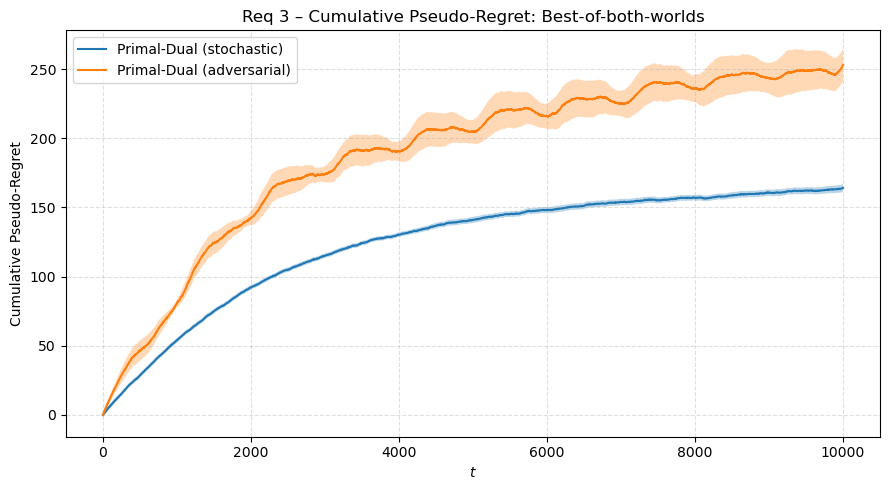

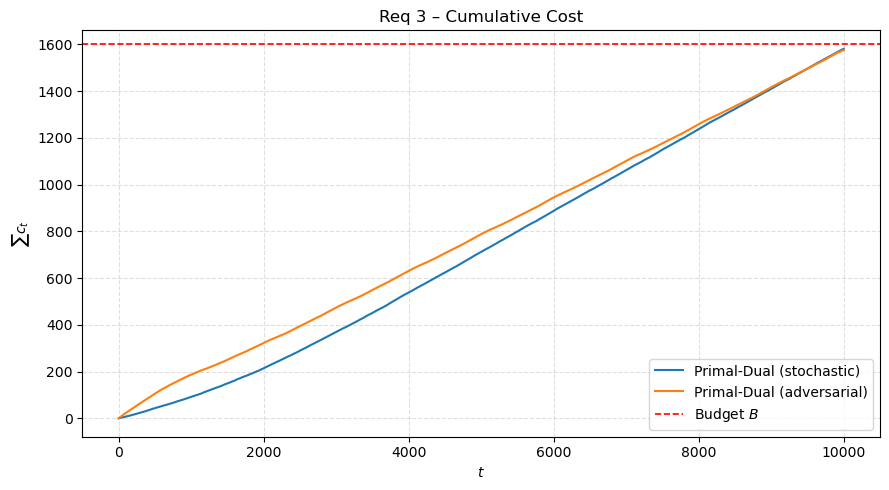

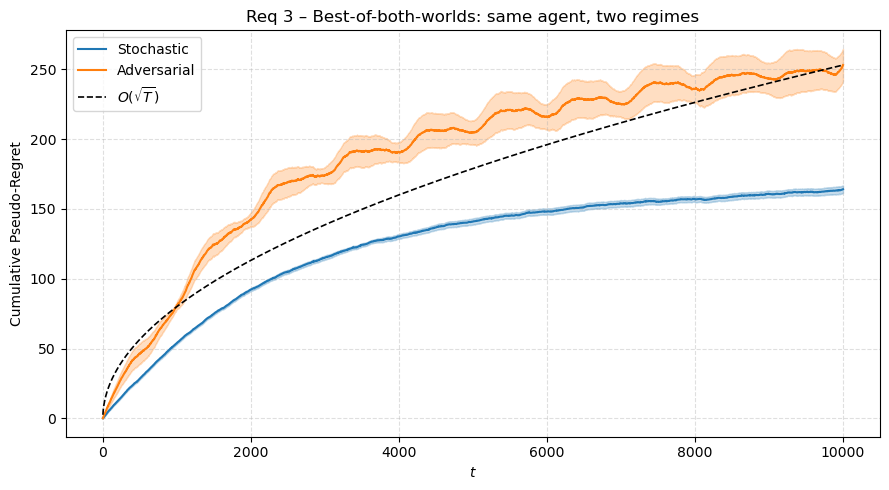

In [3]:
from utils.run_req3 import run_req3
run_req3()

## Results Summary

Final cumulative pseudo-regret and budget utilisation for both experiments. The adversarial regret is measured against OPT$^A$ (best fixed distribution in hindsight), computed per trial from the empirical win probabilities of the realised sequence.

In [4]:
try:
    res_stoch = load_pickle("req3_stochastic_results.pkl")
    res_adv   = load_pickle("req3_adversarial_results.pkl")
except FileNotFoundError as _e:
    display(Markdown(f"**Run the `run_req3()` cell above first, then re-run this cell.**\n\n`{_e}`"))
    raise

for label, res in [("Stochastic (vs LP optimum)", res_stoch),
                   ("Adversarial (vs OPT^A)", res_adv)]:
    T_run = len(res["mean_regret"])
    print(f"{label}:")
    print(f"  Trials         = {res['n_trials']}")
    print(f"  Final regret   = {res['mean_regret'][-1]:.2f}")
    print(f"  Average regret = {res['mean_regret'][-1] / T_run:.5f}")
    print(f"  Final cost     = {res['mean_cumcost'][-1]:.2f} / {BUDGET:.0f}")
    print(f"  Final λ        = {res['mean_lmbd'][-1]:.4f}")
    print()